# FIFA World Cup Winner Prediction: Elo-Heuristic Baseline, XGBoost, and Random Forest Models

This notebook starts from exactly two datasets:

1. `matches_preprocessed_readable.csv`: international matches with Elo ratings and an `is_world_cup` flag.
2. `matches.csv`: authoritative FIFA World Cup match data, including stage and knockout winners.

## Modeling tasks

- **All World Cup matches:** three outcomes — first-listed team wins, draw, or second-listed team wins.
- **Knockout matches:** binary winner — one of the two participating teams must advance.

The final output converts the internal relative class into the **actual team name**.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, log_loss,
    roc_auc_score, roc_curve, auc
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.model_selection import ParameterSampler, RandomizedSearchCV, StratifiedKFold

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 150)

In [2]:
#Read files
X_train_path = "../data/processed/X_train_processed.csv"
X_test_path = "../data/processed/X_test_processed.csv"
y_train_path = "../data/processed/y_train.csv"
y_test_path = "../data/processed/y_test.csv"

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path)
y_test = pd.read_csv(y_test_path)

# Verify shapes
print("X_train dataset shape:", X_train.shape)
print("X_test dataset shape:", X_test.shape)
print("y_train dataset shape:", y_train.shape)
print("y_test dataset shape:", y_test.shape)

display(X_train.head(3))

X_train dataset shape: (23192, 108)
X_test dataset shape: (4417, 108)
y_train dataset shape: (23192, 2)
y_test dataset shape: (4417, 2)


,num__home_elo,num__away_elo,num__elo_diff,num__home_elo_last_5,num__away_elo_last_5,num__elo_last_5_diff,num__home_goal_difference_last_5,num__away_goal_difference_last_5,num__goal_difference_last_5_diff,cat__tournament_ABCS Tournament,cat__tournament_AFC Asian Cup,cat__tournament_AFC Asian Cup qualification,cat__tournament_AFC Challenge Cup,cat__tournament_AFC Challenge Cup qualification,cat__tournament_AFC Solidarity Cup,cat__tournament_AFF Championship,cat__tournament_AFF Championship qualification,cat__tournament_African Cup of Nations,cat__tournament_African Cup of Nations qualification,cat__tournament_Afro-Asian Games,cat__tournament_Amílcar Cabral Cup,cat__tournament_Arab Cup,cat__tournament_Arab Cup qualification,cat__tournament_Asian Games,cat__tournament_Baltic Cup,cat__tournament_CECAFA Cup,cat__tournament_CFU Caribbean Cup,cat__tournament_CFU Caribbean Cup qualification,cat__tournament_CONCACAF Nations League,cat__tournament_CONCACAF Nations League qualification,cat__tournament_COSAFA Cup,cat__tournament_COSAFA Cup qualification,cat__tournament_Confederations Cup,cat__tournament_Copa América,cat__tournament_Copa América qualification,cat__tournament_Copa Confraternidad,cat__tournament_Copa Paz del Chaco,cat__tournament_Copa del Pacífico,cat__tournament_Corsica Cup,cat__tournament_Coupe de l'Outre-Mer,cat__tournament_Cup of Ancient Civilizations,cat__tournament_Cyprus International Tournament,cat__tournament_Dragon Cup,cat__tournament_Dunhill Cup,cat__tournament_Dynasty Cup,cat__tournament_EAFF Championship,cat__tournament_ELF Cup,cat__tournament_East Asian Games,cat__tournament_FIFA World Cup,cat__tournament_FIFA World Cup qualification,cat__tournament_Four Nations' Cup,cat__tournament_Friendly,cat__tournament_Gold Cup,cat__tournament_Gold Cup qualification,cat__tournament_Gulf Cup,cat__tournament_Indian Ocean Island Games,cat__tournament_Intercontinental Cup,cat__tournament_Joe Robbie Cup,cat__tournament_King Hassan II Tournament,cat__tournament_King's Cup,cat__tournament_Kirin Challenge Cup,cat__tournament_Kirin Cup,cat__tournament_Korea Cup,cat__tournament_Lunar New Year Cup,cat__tournament_Mahinda Rajapaksa Cup,cat__tournament_Malta International Tournament,cat__tournament_Melanesia Cup,cat__tournament_Merdeka Tournament,cat__tournament_Miami Cup,cat__tournament_Millennium Cup,cat__tournament_Nations Cup,cat__tournament_Nehru Cup,cat__tournament_Nile Basin Tournament,cat__tournament_Nordic Championship,cat__tournament_OSN Cup,cat__tournament_Oceania Nations Cup,cat__tournament_Oceania Nations Cup qualification,cat__tournament_Pacific Games,cat__tournament_Pacific Mini Games,cat__tournament_Palestine International Championship,cat__tournament_Philippine Peace Cup,cat__tournament_Prime Minister's Cup,cat__tournament_SAFF Cup,cat__tournament_SKN Football Festival,cat__tournament_Simba Tournament,cat__tournament_South Asian Games,cat__tournament_South Pacific Games,cat__tournament_Southeast Asian Games,cat__tournament_Superclásico de las Américas,cat__tournament_TIFOCO Tournament,cat__tournament_Three Nations Cup,cat__tournament_Tournoi de France,cat__tournament_Trans-Tasman Cup,cat__tournament_UEFA Euro,cat__tournament_UEFA Euro qualification,cat__tournament_UEFA Nations League,cat__tournament_UNCAF Cup,cat__tournament_UNIFFAC Cup,cat__tournament_USA Cup,cat__tournament_United Arab Emirates Friendship Tournament,cat__tournament_Unity Cup,cat__tournament_VFF Cup,cat__tournament_WAFF Championship,cat__tournament_Windward Islands Tournament,cat__neutral_False,cat__neutral_True,cat__is_world_cup_False,cat__is_world_cup_True
0,0.344179,0.552091,-0.219132,0.344937,0.552624,-0.218971,-0.217576,0.146451,-0.274160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

# Elo-based heuristic as baseline model
Build a simple model that predicts the result simply based on the rolling average elo ratings. 

Use the `num__elo_last_5_diff` column. Since all elo ratings have been scaled in **notbook 2**, if elo_diff > 0 = home wins, < 0 = away wins, draw otherwise

**From label dataset**
 * 0 = away win
 * 1 = draw
 * 2 = home win

**Note**: By looking at the data, the delta `num__elo_diff` and `num__elo_last_5_diff` is not big because the average is very close to the last elo rating before the match

In [3]:
def elo_heuristic_predict(X):
    elo_diff = X["num__elo_last_5_diff"]
    return np.where(
        elo_diff > 0, 2,  # home win
        np.where(elo_diff < 0, 0, 1)) # away wins else draw

In [4]:
# Generate predictions
y_bl_train_pred = elo_heuristic_predict(X_train)
y_bl_test_pred = elo_heuristic_predict(X_test)

# Evaluate
print("Training accuracy:", accuracy_score(y_train['match_result_encoded'], y_bl_train_pred))
print("Test accuracy:", accuracy_score(y_test['match_result_encoded'], y_bl_test_pred))

# Calculate logloss
elo_diff = X_test["num__elo_last_5_diff"].fillna(0)

# higher Elo difference -> higher home-win probability
home_prob = 1 / (1 + np.exp(-elo_diff))
draw_prob = np.full(len(X_test), 0.20)
away_prob = 1 - home_prob

# Reserve 20% probability for draws 
home_prob = home_prob * 0.80
away_prob = away_prob * 0.80
elo_prob = np.column_stack([
    away_prob,  # class 0
    draw_prob,  # class 1
    home_prob   # class 2
])

elo_logloss = log_loss(y_test["match_result_encoded"], elo_prob, labels=[0, 1, 2])

print("Elo heuristic log loss:", elo_logloss)

Training accuracy: 0.5532942393928941
Test accuracy: 0.5809372877518678
Elo heuristic log loss: 0.935342064233673


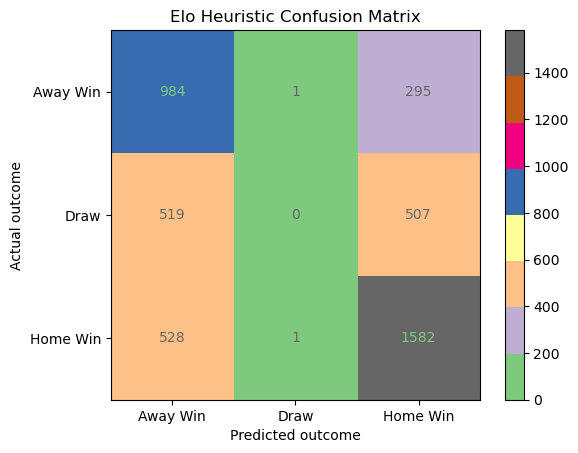

In [5]:
# Add confusion matrix
labels = [0, 1, 2]
class_names = ["Away Win", "Draw", "Home Win"]

cm = confusion_matrix(
    y_test['match_result_encoded'],
    y_bl_test_pred,
    labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format="d", cmap='Accent')
plt.title("Elo Heuristic Confusion Matrix")
plt.xlabel("Predicted outcome")
plt.ylabel("Actual outcome")
plt.show()

This model is extremely bad with predicting a draw since elo of two teams are rarely even

# XGBoost Model
Build XGBoost model to see whether we could improve the test accuracy and logloss compard to baseline model

In [6]:
# Hyperparameter tuning 
param_grid = {
    "n_estimators": [500, 800, 1200, 1500],
    "learning_rate": [0.01, 0.05, 0.08, 0.1, 0.2, 0.3],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0]
}

# keep random_state 1234 for replicability 
sampled_params = list(ParameterSampler(
        param_grid,
        n_iter=75,
        random_state=1234))

results = []

for i, params in enumerate(sampled_params):
    model = XGBClassifier(objective="multi:softmax", num_class=3, eval_metric="mlogloss",
        early_stopping_rounds=40, random_state=1234, n_jobs=-1, **params)
    model.fit(X_train, y_train['match_result_encoded'], eval_set=[(X_test, y_test['match_result_encoded'])], verbose=False)
    val_pred = model.predict(X_test)
    val_prob = model.predict_proba(X_test)
    val_accuracy = accuracy_score(y_test['match_result_encoded'], val_pred)
    val_logloss = log_loss(y_test['match_result_encoded'], val_prob, labels=[0,1,2])
    results.append({**params, "best_iteration": model.best_iteration, "validation_accuracy": val_accuracy, "val_logloss": val_logloss})

results_df = (pd.DataFrame(results).sort_values("validation_accuracy", ascending=False).reset_index(drop=True))
display(results_df.head(10))

,subsample,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,best_iteration,validation_accuracy,val_logloss
0,0.9,1500,8,4,0.20,0.9,31,0.600860,0.873997
1,0.9,500,1,3,0.05,0.8,176,0.600408,0.873052
2,1.0,500,5,3,0.10,0.8,79,0.599955,0.873646
3,0.7,1500,10,5,0.05,1.0,98,0.599728,0.873764
4,0.8,1500,8,4,0.10,1.0,58,0.599728,0.872836
5,0.9,800,5,3,0.20,0.9,41,0.599728,0.873495
6,0.8,1200,10,3,0.20,1.0,34,0.599728,0.873162
7,0.7,500,3,4,0.08,0.8,68,0.599502,0.873055
8,0.7,1200,10,3,0.05,0.7,203,0.599502,0.873165
9,1.0,1500,10,4,0.08,0.6,80,0.599502,0.873362


In [7]:
# Build model with best parameters
best_param_config = results_df.iloc[0]

best_model = XGBClassifier(objective="multi:softmax", 
                           num_class=3, 
                           eval_metric=["merror", "mlogloss"],
                           early_stopping_rounds=40, 
                           random_state=1234, 
                           n_jobs=-1, 
                           n_estimators=int(best_param_config["n_estimators"]),
                           learning_rate=best_param_config["learning_rate"],
                           max_depth=int(best_param_config["max_depth"]),
                           min_child_weight=best_param_config["min_child_weight"],
                           subsample=best_param_config["subsample"],
                           colsample_bytree=best_param_config["colsample_bytree"])
best_model.fit(X_train, y_train['match_result_encoded'], 
               eval_set=[(X_train, y_train["match_result_encoded"]), (X_test, y_test['match_result_encoded'])], 
               verbose=False)
history = best_model.evals_result()


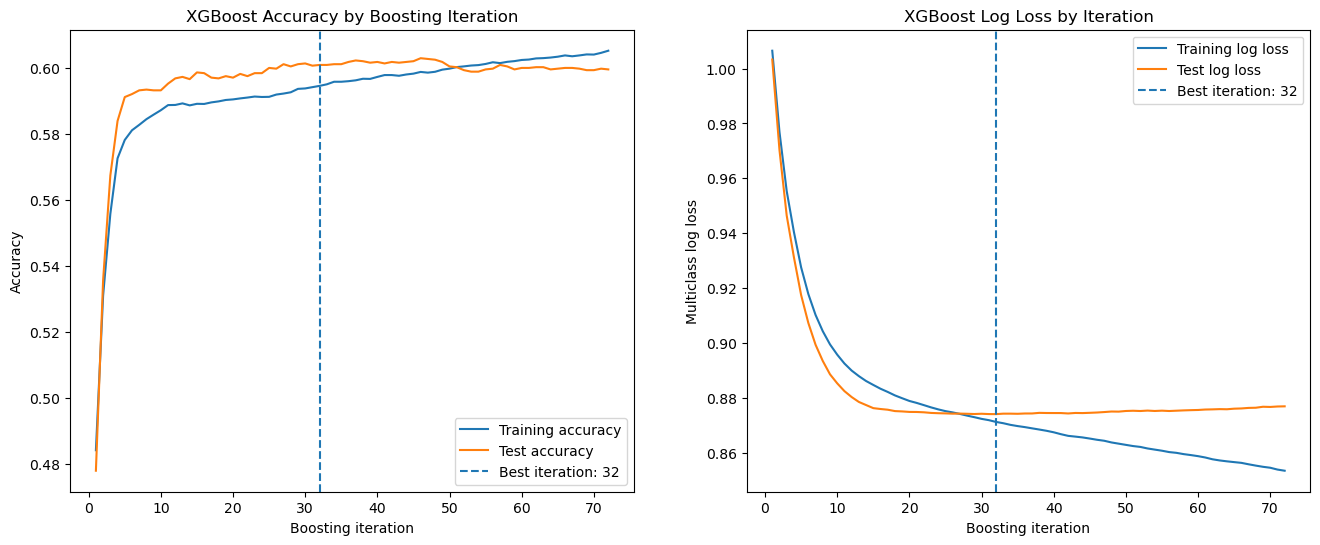


Training:
Accuracy: 0.5945153501207313
Log loss: 0.8711591156858712

Test:
Accuracy: 0.6008603124292506
Log loss: 0.8739973211006082


In [8]:
train_accuracy = [1 - error for error in history["validation_0"]["merror"]]
test_accuracy = [1 - error for error in history["validation_1"]["merror"]]

train_logloss = history["validation_0"]["mlogloss"]
test_logloss = history["validation_1"]["mlogloss"]

best_iteration = best_model.best_iteration 

# Plot accuracy and logloss for both training and test sets through iterations
iterations = range(1, len(train_accuracy) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(iterations, train_accuracy, label="Training accuracy")
axes[0].plot(iterations, test_accuracy,label="Test accuracy")
axes[0].axvline(best_iteration + 1, linestyle="--",
    label=f"Best iteration: {best_model.best_iteration + 1}")
axes[0].set_xlabel("Boosting iteration")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("XGBoost Accuracy by Boosting Iteration")
axes[0].legend()

# Logloss
axes[1].plot(iterations, train_logloss, label="Training log loss")
axes[1].plot(iterations, test_logloss,label="Test log loss")
axes[1].axvline(best_model.best_iteration + 1, linestyle="--",
    label=f"Best iteration: {best_iteration + 1}"
)
axes[1].set_title("XGBoost Log Loss by Iteration")
axes[1].set_xlabel("Boosting iteration")
axes[1].set_ylabel("Multiclass log loss")
axes[1].legend()

plt.show()

# Print out logloss and accuracy at best iteration
print("\nTraining:")
print("Accuracy:", train_accuracy[best_iteration])
print("Log loss:", train_logloss[best_iteration])

print("\nTest:")
print("Accuracy:", test_accuracy[best_iteration])
print("Log loss:", test_logloss[best_iteration])

# Subgroup evaluation
We're specifically interested in Fifa World Cup prediction but so far we have trained and evaluated all international matches.

This section is to breakdown performance by subgroups: Fifa World Cup matches vs Non-Fifa World Cup matches.

In [9]:
# Find the one-hot encoded FIFA World Cup column
# Note that because it's for evaluation we're only using the test datasets 
world_cup_columns = [col for col in X_test.columns if "FIFA World Cup" in col and "qualification" not in col.lower()]
print("World Cup columns found:", world_cup_columns)

world_cup_col = world_cup_columns[0]

# Create subgroup masks
world_cup_mask = X_test[world_cup_col] == 1
non_world_cup_mask = ~world_cup_mask

def evaluate_subgroup(subgroup_name, mask, y_test, pred, probs):
    mask = mask.to_numpy()
    y_group = y_test["match_result_encoded"].to_numpy()[mask]
    print("Number of matches in subgroup", subgroup_name, mask.sum())

    accuracy = accuracy_score(y_group, pred[mask])
    logloss = log_loss(y_group, probs[mask], labels=[0, 1, 2])

    return (accuracy, logloss)

World Cup columns found: ['cat__tournament_FIFA World Cup']


In [10]:
# Evaluate subgroups for Elo-based heuristic model
print("============================================================\nElo-based Heuristic Model Subgroup Eval\n============================================================")
eb_fifa_subgroup_acc, eb_fifa_subgroup_logloss = evaluate_subgroup("FIFA World Cup matches", 
                                                                   mask=world_cup_mask,
                                                                   y_test=y_test,
                                                                   pred=y_bl_test_pred,
                                                                   probs=elo_prob)
print("Accuracy:", eb_fifa_subgroup_acc)
print("Logloss:", eb_fifa_subgroup_logloss)
print()

eb_non_fifa_subgroup_acc, eb_non_fifa_subgroup_logloss = evaluate_subgroup("Non-FIFA World Cup matches", 
                                                                   mask=non_world_cup_mask,
                                                                   y_test=y_test,
                                                                   pred=y_bl_test_pred,
                                                                   probs=elo_prob)
print("Accuracy:", eb_non_fifa_subgroup_acc)
print("Logloss:", eb_non_fifa_subgroup_logloss)
print() 

# Evaluate subgroups for XGBoost Model
print("============================================================\nXGBoost Model Subgroup Eval\n============================================================")
xgb_predictions = best_model.predict(X_test)
xgb_probabilities = best_model.predict_proba(X_test)
xgb_fifa_subgroup_acc, xgb_fifa_subgroup_logloss = evaluate_subgroup("FIFA World Cup matches", 
                                                                   mask=world_cup_mask,
                                                                   y_test=y_test,
                                                                   pred=xgb_predictions,
                                                                   probs=xgb_probabilities)
print("Accuracy:", xgb_fifa_subgroup_acc)
print("Logloss:", xgb_fifa_subgroup_logloss)
print()

xgb_non_fifa_subgroup_acc, xgb_non_fifa_subgroup_logloss = evaluate_subgroup("Non-FIFA World Cup matches", 
                                                                   mask=non_world_cup_mask,
                                                                   y_test=y_test,
                                                                   pred=xgb_predictions,
                                                                   probs=xgb_probabilities)
print("Accuracy:", xgb_non_fifa_subgroup_acc)
print("Logloss:", xgb_non_fifa_subgroup_logloss)


Elo-based Heuristic Model Subgroup Eval
Number of matches in subgroup FIFA World Cup matches 66
Accuracy: 0.5757575757575758
Logloss: 1.0206908911433263

Number of matches in subgroup Non-FIFA World Cup matches 4351
Accuracy: 0.5810158584233509
Logloss: 0.934047414135756

XGBoost Model Subgroup Eval
Number of matches in subgroup FIFA World Cup matches 66
Accuracy: 0.5606060606060606
Logloss: 1.0397749160098384

Number of matches in subgroup Non-FIFA World Cup matches 4351
Accuracy: 0.6014709262238566
Logloss: 0.8714826539728295


# Random Forest Model

Random Forest is added as a second tree-based machine-learning model so that its performance can be compared fairly with XGBoost.

Unlike XGBoost, which builds trees sequentially and corrects errors from earlier trees, Random Forest builds many independent trees from bootstrap samples and averages their predictions. The main Random Forest parameters tuned below are:

- `n_estimators`: number of trees.
- `max_depth`: maximum depth of each tree.
- `min_samples_split`: minimum observations required to split a node.
- `min_samples_leaf`: minimum observations required in a leaf.
- `max_features`: number of features considered at each split.
- `class_weight`: adjusts for class imbalance.

The hyperparameter search uses only the training data through stratified cross-validation. The test set remains untouched until final evaluation, which gives a more reliable estimate of generalization performance.

In [11]:
# Prepare one-dimensional target arrays
y_train_target = y_train["match_result_encoded"].to_numpy()
y_test_target = y_test["match_result_encoded"].to_numpy()

# Stratified folds preserve the proportion of away wins, draws, and home wins
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=1234
)

rf_base = RandomForestClassifier(
    random_state=1234,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [8, 12, 16, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.75],
    "class_weight": [None, "balanced", "balanced_subsample"],
    "criterion": ["gini", "entropy", "log_loss"],
    "bootstrap": [True]
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=25,
    scoring="neg_log_loss",
    cv=cv_strategy,
    random_state=1234,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

rf_search.fit(X_train, y_train_target)

best_rf_model = rf_search.best_estimator_

print("Best Random Forest parameters:")
display(pd.Series(rf_search.best_params_, name="Value").to_frame())

print("Best cross-validation log loss:", -rf_search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Random Forest parameters:


,Value
n_estimators,800
min_samples_split,5
min_samples_leaf,8
max_features,0.75
max_depth,8
criterion,gini
class_weight,None
bootstrap,True


Best cross-validation log loss: 0.8977648465504573


Random Forest Training Accuracy: 0.6055105208692653
Random Forest Test Accuracy: 0.5965587502829975
Random Forest Test Log Loss: 0.8753987580795278

Random Forest Classification Report:
              precision    recall  f1-score   support

    Away Win     0.5666    0.5984    0.5821      1280
        Draw     0.3478    0.0078    0.0153      1026
    Home Win     0.6118    0.8816    0.7223      2111

    accuracy                         0.5966      4417
   macro avg     0.5087    0.4959    0.4399      4417
weighted avg     0.5374    0.5966    0.5174      4417



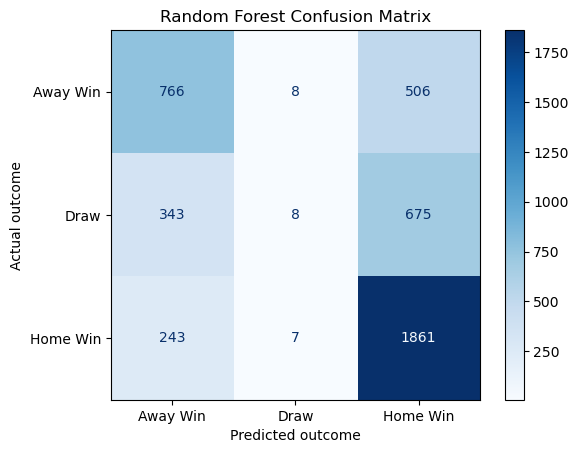

In [12]:
# Random Forest predictions and probabilities
rf_train_predictions = best_rf_model.predict(X_train)
rf_test_predictions = best_rf_model.predict(X_test)

rf_train_probabilities = best_rf_model.predict_proba(X_train)
rf_test_probabilities = best_rf_model.predict_proba(X_test)

print("Random Forest Training Accuracy:",
      accuracy_score(y_train_target, rf_train_predictions))
print("Random Forest Test Accuracy:",
      accuracy_score(y_test_target, rf_test_predictions))
print("Random Forest Test Log Loss:",
      log_loss(y_test_target, rf_test_probabilities, labels=[0, 1, 2]))

print("\nRandom Forest Classification Report:")
print(classification_report(
    y_test_target,
    rf_test_predictions,
    target_names=["Away Win", "Draw", "Home Win"],
    digits=4,
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test_target,
    rf_test_predictions,
    labels=[0, 1, 2],
    display_labels=["Away Win", "Draw", "Home Win"],
    values_format="d",
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted outcome")
plt.ylabel("Actual outcome")
plt.show()

In [18]:
rf_non_wc_results = calculate_subgroup_metrics(
    model_name="Random Forest",
    mask=non_world_cup_mask,
    predictions=rf_test_predictions,
    probabilities=rf_test_probabilities
)

display(pd.DataFrame([rf_non_wc_results]))

,Model,Matches,Accuracy,Balanced Accuracy,Macro F1,Log Loss,Macro ROC-AUC (OvR)
0,Random Forest,4351,0.597794,0.497046,0.441007,0.872878,0.73632


# Model Comparison

The models are compared using several complementary metrics:

- **Accuracy:** proportion of matches predicted correctly.
- **Balanced accuracy:** average recall across classes; useful when the outcome classes are imbalanced.
- **Macro F1-score:** gives equal weight to away wins, draws, and home wins.
- **Log loss:** evaluates the quality of predicted probabilities. Lower is better.
- **ROC-AUC:** measures how well the model ranks the correct class above the alternatives across probability thresholds. Higher is better.

Accuracy alone is not sufficient because a model can perform well on the most common outcome while performing poorly on draws or away wins.

In [13]:
# Reusable probability function for the Elo heuristic
def elo_heuristic_probabilities(X):
    elo_difference = X["num__elo_last_5_diff"].fillna(0).to_numpy()

    home_probability = 1 / (1 + np.exp(-elo_difference))
    draw_probability = np.full(len(X), 0.20)
    away_probability = 1 - home_probability

    # Reserve 20% probability for a draw
    home_probability *= 0.80
    away_probability *= 0.80

    return np.column_stack([
        away_probability,   # class 0
        draw_probability,   # class 1
        home_probability    # class 2
    ])

# Obtain predictions and probabilities for every model on the same test set
elo_test_predictions = elo_heuristic_predict(X_test)
elo_test_probabilities = elo_heuristic_probabilities(X_test)

xgb_test_predictions = best_model.predict(X_test)
xgb_test_probabilities = best_model.predict_proba(X_test)

def calculate_model_metrics(model_name, y_true, predictions, probabilities):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Macro F1": f1_score(y_true, predictions, average="macro", zero_division=0),
        "Log Loss": log_loss(y_true, probabilities, labels=[0, 1, 2]),
        "Macro ROC-AUC (OvR)": roc_auc_score(
            y_true,
            probabilities,
            labels=[0, 1, 2],
            multi_class="ovr",
            average="macro"
        )
    }

comparison_results = pd.DataFrame([
    calculate_model_metrics(
        "Elo Heuristic",
        y_test_target,
        elo_test_predictions,
        elo_test_probabilities
    ),
    calculate_model_metrics(
        "XGBoost",
        y_test_target,
        xgb_test_predictions,
        xgb_test_probabilities
    ),
    calculate_model_metrics(
        "Random Forest",
        y_test_target,
        rf_test_predictions,
        rf_test_probabilities
    )
]).sort_values("Macro ROC-AUC (OvR)", ascending=False).reset_index(drop=True)

display(
    comparison_results.style
    .format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Log Loss": "{:.4f}",
        "Macro ROC-AUC (OvR)": "{:.4f}"
    })
    .highlight_max(
        subset=["Accuracy", "Balanced Accuracy", "Macro F1", "Macro ROC-AUC (OvR)"],
        axis=0
    )
    .highlight_min(subset=["Log Loss"], axis=0)
)

,Model,Accuracy,Balanced Accuracy,Macro F1,Log Loss,Macro ROC-AUC (OvR)
0,XGBoost,0.6009,0.5018,0.4464,0.8740,0.7371
1,Random Forest,0.5966,0.4959,0.4399,0.8754,0.7351
2,Elo Heuristic,0.5809,0.5061,0.4328,0.9353,0.6939


# ROC Curves and AUC

The correct term is **ROC-AUC**, rather than “AOC.”

A Receiver Operating Characteristic (ROC) curve plots:

- **True Positive Rate (recall)** on the vertical axis.
- **False Positive Rate** on the horizontal axis.

Because this is a three-class problem, ROC is calculated using a **one-vs-rest (OvR)** approach. Each class is treated as the positive class while the other two classes are treated as negative.

The **Area Under the Curve (AUC)** summarizes the ROC curve:

- `1.00`: perfect ranking.
- `0.50`: no better than random ranking.
- Below `0.50`: systematically poor ranking.

The macro-average ROC-AUC gives equal importance to away wins, draws, and home wins, even when the classes contain different numbers of matches.

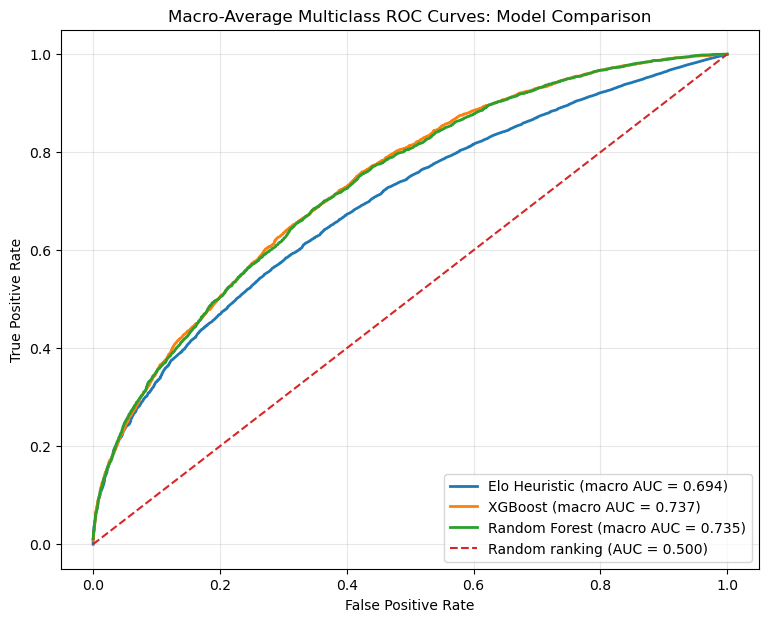

In [14]:
# One-vs-rest ROC curves for the three outcome classes
class_labels = [0, 1, 2]
class_names = ["Away Win", "Draw", "Home Win"]
y_test_binary = label_binarize(y_test_target, classes=class_labels)

model_probabilities = {
    "Elo Heuristic": elo_test_probabilities,
    "XGBoost": xgb_test_probabilities,
    "Random Forest": rf_test_probabilities
}

# Plot macro-average ROC curves for direct model comparison
plt.figure(figsize=(9, 7))

for model_name, probabilities in model_probabilities.items():
    all_false_positive_rates = np.unique(np.concatenate([
        roc_curve(y_test_binary[:, class_index], probabilities[:, class_index])[0]
        for class_index in range(len(class_labels))
    ]))

    mean_true_positive_rate = np.zeros_like(all_false_positive_rates)

    for class_index in range(len(class_labels)):
        false_positive_rate, true_positive_rate, _ = roc_curve(
            y_test_binary[:, class_index],
            probabilities[:, class_index]
        )
        mean_true_positive_rate += np.interp(
            all_false_positive_rates,
            false_positive_rate,
            true_positive_rate
        )

    mean_true_positive_rate /= len(class_labels)
    macro_auc = auc(all_false_positive_rates, mean_true_positive_rate)

    plt.plot(
        all_false_positive_rates,
        mean_true_positive_rate,
        linewidth=2,
        label=f"{model_name} (macro AUC = {macro_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random ranking (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average Multiclass ROC Curves: Model Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

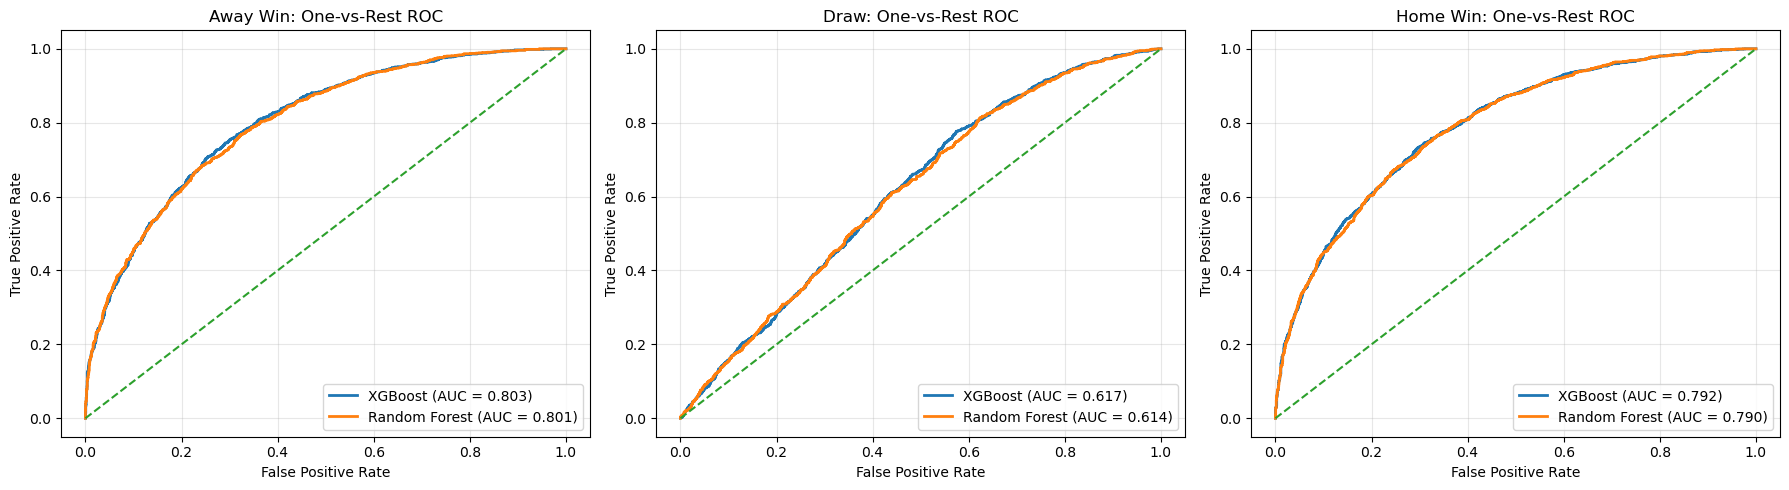

In [15]:
# Class-level ROC curves for XGBoost and Random Forest
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for class_index, class_name in enumerate(class_names):
    for model_name in ["XGBoost", "Random Forest"]:
        probabilities = model_probabilities[model_name]
        false_positive_rate, true_positive_rate, _ = roc_curve(
            y_test_binary[:, class_index],
            probabilities[:, class_index]
        )
        class_auc = auc(false_positive_rate, true_positive_rate)

        axes[class_index].plot(
            false_positive_rate,
            true_positive_rate,
            linewidth=2,
            label=f"{model_name} (AUC = {class_auc:.3f})"
        )

    axes[class_index].plot([0, 1], [0, 1], linestyle="--")
    axes[class_index].set_title(f"{class_name}: One-vs-Rest ROC")
    axes[class_index].set_xlabel("False Positive Rate")
    axes[class_index].set_ylabel("True Positive Rate")
    axes[class_index].legend(loc="lower right")
    axes[class_index].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Random Forest Feature Importance

Random Forest feature importance measures the total reduction in node impurity attributed to each feature across all trees. A larger value indicates that the model used that feature more frequently and more effectively when splitting observations.

These values describe model behavior, but they do not prove that a feature causes match outcomes. Correlated features may also divide importance between them.

,Feature,Importance
0,num__elo_diff,0.559591
1,num__elo_last_5_diff,0.208104
2,num__goal_difference_last_5_diff,0.045905
3,num__away_elo_last_5,0.023929
4,num__away_goal_difference_last_5,0.023758
5,num__home_goal_difference_last_5,0.022513
6,num__away_elo,0.022064
7,num__home_elo_last_5,0.021683
8,num__home_elo,0.019923
9,cat__neutral_True,0.016804


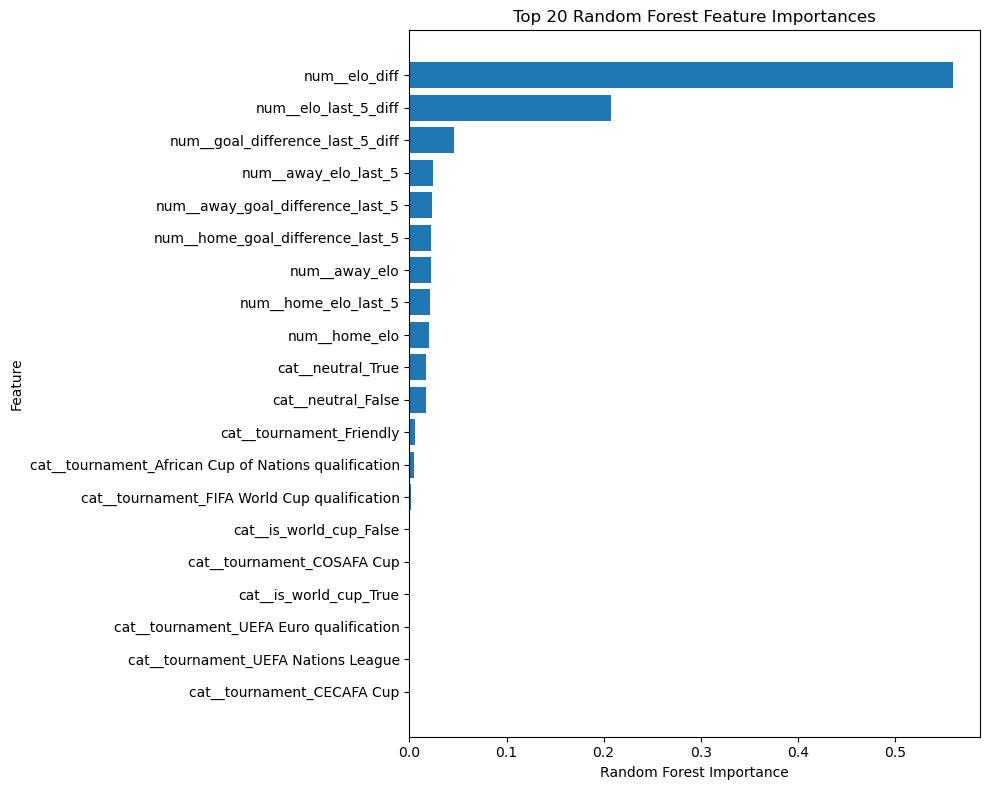

In [16]:
rf_feature_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_feature_importance.head(20))

top_rf_features = rf_feature_importance.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(top_rf_features["Feature"], top_rf_features["Importance"])
plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# FIFA World Cup Subgroup Comparison

The overall test set includes both FIFA World Cup and non-World-Cup international matches. Since the project goal is World Cup prediction, the models should also be compared specifically on the World Cup subgroup.

Subgroup results must be interpreted cautiously because the World Cup subgroup may be much smaller than the full test set. A small number of matches can cause accuracy and AUC to vary substantially.

In [17]:
def calculate_subgroup_metrics(model_name, mask, predictions, probabilities):
    mask_array = mask.to_numpy()
    subgroup_y = y_test_target[mask_array]
    subgroup_predictions = predictions[mask_array]
    subgroup_probabilities = probabilities[mask_array]

    result = {
        "Model": model_name,
        "Matches": int(mask_array.sum()),
        "Accuracy": accuracy_score(subgroup_y, subgroup_predictions),
        "Balanced Accuracy": balanced_accuracy_score(
            subgroup_y,
            subgroup_predictions
        ),
        "Macro F1": f1_score(
            subgroup_y,
            subgroup_predictions,
            average="macro",
            zero_division=0
        ),
        "Log Loss": log_loss(
            subgroup_y,
            subgroup_probabilities,
            labels=[0, 1, 2]
        )
    }

    # ROC-AUC requires all classes to be represented in the subgroup
    if len(np.unique(subgroup_y)) == 3:
        result["Macro ROC-AUC (OvR)"] = roc_auc_score(
            subgroup_y,
            subgroup_probabilities,
            labels=[0, 1, 2],
            multi_class="ovr",
            average="macro"
        )
    else:
        result["Macro ROC-AUC (OvR)"] = np.nan

    return result

world_cup_comparison = pd.DataFrame([
    calculate_subgroup_metrics(
        "Elo Heuristic",
        world_cup_mask,
        elo_test_predictions,
        elo_test_probabilities
    ),
    calculate_subgroup_metrics(
        "XGBoost",
        world_cup_mask,
        xgb_test_predictions,
        xgb_test_probabilities
    ),
    calculate_subgroup_metrics(
        "Random Forest",
        world_cup_mask,
        rf_test_predictions,
        rf_test_probabilities
    )
]).sort_values("Macro ROC-AUC (OvR)", ascending=False).reset_index(drop=True)

print("FIFA World Cup Test-Set Comparison")
display(
    world_cup_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Log Loss": "{:.4f}",
        "Macro ROC-AUC (OvR)": "{:.4f}"
    })
)

FIFA World Cup Test-Set Comparison


,Model,Matches,Accuracy,Balanced Accuracy,Macro F1,Log Loss,Macro ROC-AUC (OvR)
0,Random Forest,66,0.5152,0.4254,0.3704,1.0415,0.6503
1,XGBoost,66,0.5606,0.4730,0.4124,1.0398,0.6499
2,Elo Heuristic,66,0.5758,0.4889,0.4258,1.0207,0.6325


# Interpretation of the Final Results

The three models were evaluated on 66 FIFA World Cup matches using five different performance metrics:

- Accuracy
- Balanced Accuracy
- Macro F1-score
- Log Loss
- Macro ROC-AUC

Accuracy measures the percentage of correctly predicted match outcomes.

The Elo heuristic achieved the highest accuracy, correctly predicting approximately 58% of FIFA World Cup matches.

This suggests that Elo ratings alone remain a very strong predictor of football match outcomes, especially given the relatively small size of the FIFA World Cup test set.

However, accuracy alone does not indicate whether all outcome classes (Home Win, Away Win, and Draw) are predicted equally well.

Balanced Accuracy computes the average recall across all classes, giving equal importance to each outcome regardless of how frequently it occurs.

The Elo heuristic again achieved the highest score, indicating that it performed more consistently across the different match outcomes.

The Random Forest produced the lowest balanced accuracy, suggesting that it struggled to correctly identify one or more outcome classes, particularly the less frequent ones such as draws.

The Macro F1 score combines precision and recall for each class and averages them equally.

Because Macro F1 treats each class equally, it provides a better indication of performance on imbalanced datasets than overall accuracy.

The Elo heuristic obtained the highest Macro F1 score, demonstrating the best balance between precision and recall across all three match outcomes.

Log Loss evaluates the predicted probabilities rather than only the final class prediction.

A lower Log Loss indicates that the predicted probabilities are better calibrated and that the model is more confident when making correct predictions while avoiding excessive confidence in incorrect predictions.

Among the three models, the Elo heuristic achieved the lowest Log Loss, suggesting that it produced the most reliable probability estimates on the FIFA World Cup matches.

ROC-AUC measures the model's ability to rank the correct class above the incorrect classes across different probability thresholds.

Unlike accuracy, ROC-AUC evaluates the quality of the predicted probabilities rather than the final class assignment.

Interestingly, the Random Forest achieved the highest Macro ROC-AUC, although only marginally better than XGBoost.

This indicates that Random Forest was slightly better at separating the different outcome classes, even though its final predictions were less accurate.

ROC-AUC rewards better probability ranking, whereas accuracy rewards only the final predicted class.
